# Supply CHain Anlysis

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import plotly.express as px
from funcs import custom_plot, custom_subplot
import numpy as np
import seaborn as sns


In [2]:
# Using cp1252 encoding
df = pd.read_csv("data.csv")
pd.set_option('display.max_columns', None)

display(df.head())



,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer City,Customer Country,Customer Id,Customer Segment,Customer State,Customer Zipcode,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,Order_Date,Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Name,Product Price,Product Status,Shipping_Date,Shipping Mode,Post_Order_Action,Transportation_Cost,Lead_Time,Supplier_ID
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,Sporting Goods,Caguas,Puerto Rico,20755,Consumer,PR,725.0,Fitness,18.251453,-66.037056,Pacific Asia,Bekasi,Indonesia,20755,2018-01-31 22:56:00,77202,1360,13.110000,0.04,180517,327.75,0.29,1,327.75,314.640015,91.250000,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,Smart watch,327.75,0,2018-02-03 22:56:00,Standard Class,NaN,23.641850,6,sup001
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,Sporting Goods,Caguas,Puerto Rico,19492,Consumer,PR,725.0,Fitness,18.279451,-66.037064,Pacific Asia,Bikaner,India,19492,2018-01-13 12:27:00,75939,1360,16.389999,0.05,179254,327.75,-0.80,1,327.75,311.359985,-249.089996,South Asia,Rajastán,PENDING,NaN,1360,73,Smart watch,327.75,0,2018-01-18 12:27:00,Standard Class,NaN,18.305349,10,sup004
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,Sporting Goods,San Jose,EE. UU.,19491,Consumer,CA,95125.0,Fitness,37.292233,-121.881279,Pacific Asia,Bikaner,India,19491,2018-01-13 12:06:00,75938,1360,18.030001,0.06,179253,327.75,-0.80,1,327.75,309.720001,-247.779999,South Asia,Rajastán,CLOSED,NaN,1360,73,Smart watch,327.75,0,2018-01-17 12:06:00,Standard Class,NaN,21.521161,8,sup004
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,Sporting Goods,Los Angeles,EE. UU.,19490,Home Office,CA,90027.0,Fitness,34.125946,-118.291016,Pacific Asia,Townsville,Australia,19490,2018-01-13 11:45:00,75937,1360,22.940001,0.07,179252,327.75,0.08,1,327.75,304.809998,22.860001,Oceania,Queensland,COMPLETE,NaN,1360,73,Smart watch,327.75,0,2018-01-16 11:45:00,Standard Class,NaN,21.390399,6,sup002
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,Sporting Goods,Caguas,Puerto Rico,19489,Corporate,PR,725.0,Fitness,18.253769,-66.037048,Pacific Asia,Townsville,Australia,19489,2018-01-13 11:24:00,75936,1360,29.500000,0.09,179251,327.75,0.45,1,327.75,298.250000,134.210007,Oceania,Queensland,PENDING_PAYMENT,NaN,1360,73,Smart watch,327.75,0,2018-01-15 11:24:00,Standard Class,NaN,26.171795,4,sup001


## **Lead Time**
It is the Total Time it takes for an order to reach customer from ordering to delivery

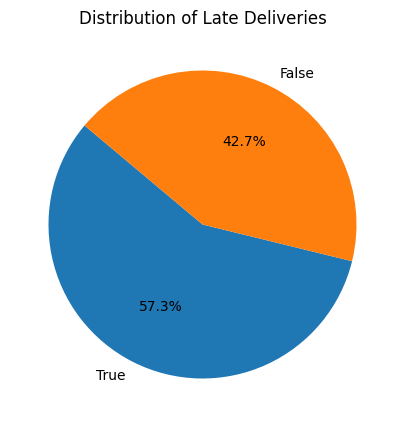

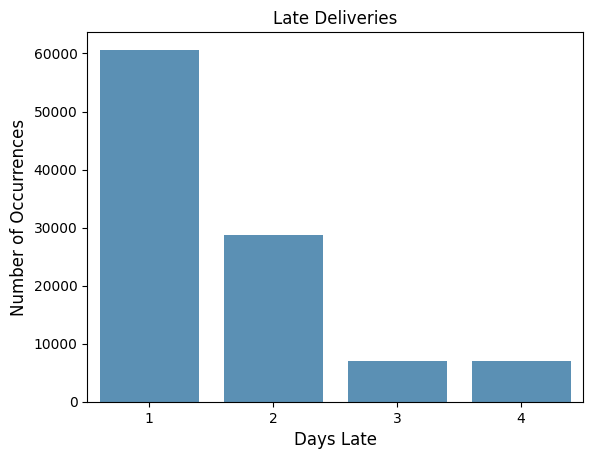

late,False,True
Shipping Mode,,
First Class,0.0,27814.0
Same Day,5080.0,4657.0
Second Class,7138.0,28078.0
Standard Class,64901.0,42851.0


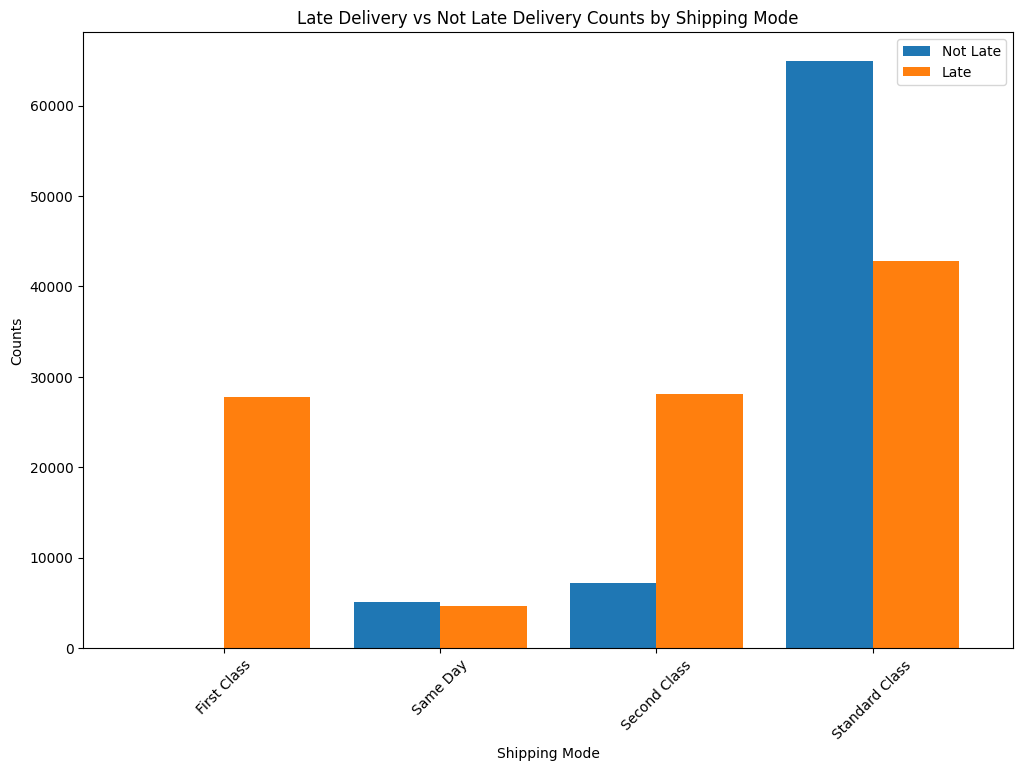

In [3]:
df['days_late']=df['Days for shipment (scheduled)']-df['Days for shipping (real)']

df['late']=df['days_late']<0
# display(df[['Days for shipment (scheduled)','Days for shipping (real)','late']])

# Calculate the counts for each category
counts = df['late'].value_counts()

# Plot the pie chart
plt.figure(figsize=(5, 5))
plt.tight_layout()

plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Late Deliveries')
plt.show()
plt.close()

late_count = abs(df['days_late'][df['late'] == True]).value_counts()

plt.figure()
sns.barplot(late_count, alpha=0.8)
plt.title('Late Deliveries')
plt.ylabel('Number of Occurrences', fontsize=12)
plt.xlabel('Days Late', fontsize=12)
plt.show()
plt.close()

# Group by 'Shipping Mode' and 'late' to get the counts
late_delivery_counts = df.groupby(['Shipping Mode', 'late']).size().reset_index(name='counts')

# Pivot the table to have 'late' statuses as columns
late_delivery_pivot = late_delivery_counts.pivot(index='Shipping Mode', columns='late', values='counts').fillna(0)
display(late_delivery_pivot)
# Rename the columns for better understanding
late_delivery_pivot.columns = ['Not Late', 'Late']

# Plot the double bar graph
ax = late_delivery_pivot.plot(kind='bar', figsize=(12, 8), width=0.8)

# Set the title and labels
ax.set_title('Late Delivery vs Not Late Delivery Counts by Shipping Mode')
ax.set_xlabel('Shipping Mode')
ax.set_ylabel('Counts')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Display the plot
plt.show()

## **Fill Rate**

In [4]:
import matplotlib.pyplot as plt

# Calculate Fill Rate (approximated)
total_orders = len(df)
on_time_orders = len(df[(df['Delivery Status'] == 'Shipping on time') | (df['Delivery Status'] == 'Advance shipping')])

fill_rate = on_time_orders / total_orders

data = {
    'Total Orders': [total_orders],
    'On Time Orders': [on_time_orders],
    'Fill Rate': [f"{fill_rate * 100:.2f}%"]
}
results_df = pd.DataFrame(data)
display(results_df)




,Total Orders,On Time Orders,Fill Rate
0,180519,73788,40.88%


## **Order Accuracy**

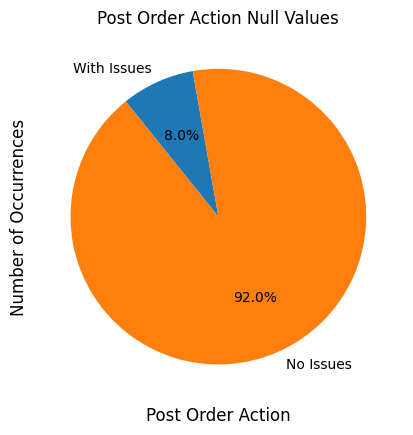

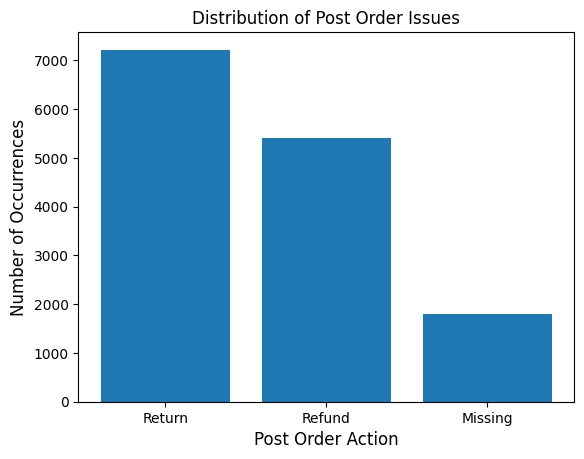

In [5]:
# Count of non-null values
non_null_count = df['Post_Order_Action'].notnull().sum()

# Count of null values
null_count = df['Post_Order_Action'].isnull().sum()

plt.figure()
plt.pie( [non_null_count, null_count],labels=['With Issues', 'No Issues'],autopct='%1.1f%%', startangle=100)
plt.title('Post Order Action Null Values')
plt.ylabel('Number of Occurrences', fontsize=12)
plt.xlabel('Post Order Action', fontsize=12)
plt.show()
plt.close()

post_order_action_count=df['Post_Order_Action'].value_counts()
plt.figure()
plt.bar(post_order_action_count.index,post_order_action_count.values)   
plt.title('Distribution of Post Order Issues')
plt.ylabel('Number of Occurrences', fontsize=12)
plt.xlabel('Post Order Action', fontsize=12)
plt.show()
plt.close()



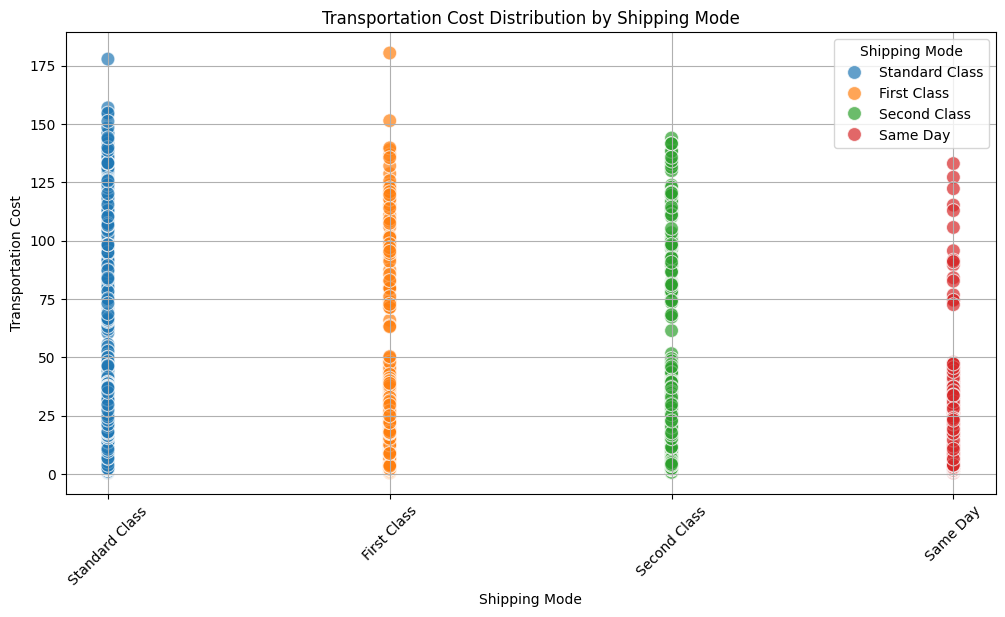

C:\Users\Admin\AppData\Local\Temp\ipykernel_3712\1513343402.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Shipping Mode', y='Transportation_Cost', data=df, palette='tab10')


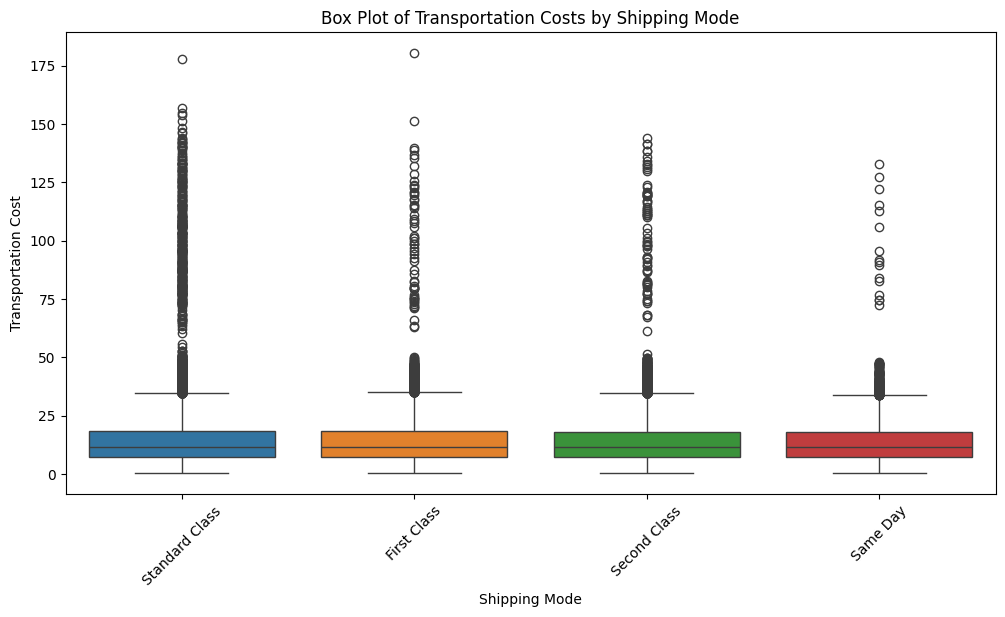

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot to show individual transportation costs by shipping mode
plt.figure(figsize=(12, 6))
sns.scatterplot(x='Shipping Mode', y='Transportation_Cost', data=df, hue='Shipping Mode', palette='tab10', alpha=0.7, s=100)

# Add titles and labels
plt.title('Transportation Cost Distribution by Shipping Mode')
plt.xlabel('Shipping Mode')
plt.ylabel('Transportation Cost')
plt.xticks(rotation=45)
plt.legend(title='Shipping Mode')
plt.grid(True)

# Show plot
plt.show()
plt.figure(figsize=(12, 6))
sns.boxplot(x='Shipping Mode', y='Transportation_Cost', data=df, palette='tab10')
plt.title('Box Plot of Transportation Costs by Shipping Mode')
plt.xlabel('Shipping Mode')
plt.ylabel('Transportation Cost')
plt.xticks(rotation=45)
plt.show()
